In [1]:
import numpy as np
import pandas as pd

In [88]:
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [3]:
df=pd.read_csv("capstone_phase3_features.csv")
df.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate,days_since_registration,visit_month,visit_year,visit_dayofweek,bill_per_hour,unapproved_gap,is_backdated
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,2,3.725000,14.865510,65,10,2025,5,5262.723214,23577.0,0
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,4,32.025000,15.691534,-206,4,2025,6,2340.833844,0.0,1
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,4,20.542500,14.967846,9,7,2025,6,142.505656,0.0,0
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,7,28.165714,15.248010,-62,11,2025,2,586.603240,0.0,1
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,5,22.988000,14.967846,0,3,2025,5,1524.578178,0.0,0


In [4]:
df.columns

Index(['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type',
       'length_of_stay_hours', 'risk_score', 'doctor_id', 'age', 'gender',
       'city', 'insurance_provider', 'chronic_flag', 'registration_date',
       'bill_id', 'billed_amount', 'approved_amount', 'claim_status',
       'payment_days', 'billing_date', 'visit_frequency',
       'avg_length_of_stay_patients', 'provider_rejection_rate',
       'days_since_registration', 'visit_month', 'visit_year',
       'visit_dayofweek', 'bill_per_hour', 'unapproved_gap', 'is_backdated'],
      dtype='object')

In [5]:
#dropping the ids
df=df.drop(columns=['patient_id','visit_id','bill_id','doctor_id'],axis=1)
df.head(10)

,visit_date,department,visit_type,length_of_stay_hours,risk_score,age,gender,city,insurance_provider,chronic_flag,...,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate,days_since_registration,visit_month,visit_year,visit_dayofweek,bill_per_hour,unapproved_gap,is_backdated
0,2025-10-18,Cardiology,ER,3.48,Low,90,M,Bangalore,CareOne,1,...,2,3.725000,14.865510,65,10,2025,5,5262.723214,23577.0,0
1,2025-04-06,Orthopedics,OPD,15.31,High,30,M,Hyderabad,SecureLife,1,...,4,32.025000,15.691534,-206,4,2025,6,2340.833844,0.0,1
2,2025-07-13,ICU,ER,34.36,Low,25,F,Chennai,HealthPlus,1,...,4,20.542500,14.967846,9,7,2025,6,142.505656,0.0,0
3,2025-11-19,Cardiology,ER,37.89,High,75,M,Delhi,MediCareX,0,...,7,28.165714,15.248010,-62,11,2025,2,586.603240,0.0,1
4,2025-03-29,General,ICU,16.78,Medium,80,M,Bangalore,HealthPlus,1,...,5,22.988000,14.967846,0,3,2025,5,1524.578178,0.0,0
5,2025-12-20,General,OPD,0.70,High,32,M,Bangalore,CareOne,0,...,3,21.033333,14.865510,24,12,2025,5,11443.529412,0.0,0
6,2025-11-12,Cardiology,OPD,6.40,Low,10,F,Bangalore,CareOne,1,...,8,10.225000,14.865510,215,11,2025,2,847.162162,1831.0,0
7,2025-09-18,ER,ICU,26.86,High,65,M,Mumbai,CareOne,0,...,5,20.314000,14.865510,-12,9,2025,3,1370.387653,0.0,1
8,2026-01-17,General,ER,8.31,Medium,51,M,Mumbai,HealthPlus,0,...,7,24.697143,14.967846,183,1,2026,5,2283.458647,0.0,0
9,2025-12-07,ER,ER,23.22,Low,49,F,Delhi,HealthPlus,1,...,9,18.795556,14.967846,157,12,2025,6,749.834847,0.0,0


In [6]:
#converting object to category
df.select_dtypes(include="object").columns

Index(['visit_date', 'department', 'visit_type', 'risk_score', 'gender',
       'city', 'insurance_provider', 'registration_date', 'claim_status',
       'billing_date'],
      dtype='object')

In [7]:
cat_cols=["department", "visit_type", "risk_score", "gender",
       "city", "insurance_provider","claim_status"]
df[cat_cols]=df[cat_cols].astype("category")

In [8]:
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['registration_date'] = pd.to_datetime(df['registration_date'])
df["billing_date"]=pd.to_datetime(df["billing_date"])

In [9]:
df.dtypes

visit_date                     datetime64[ns]
department                           category
visit_type                           category
length_of_stay_hours                  float64
risk_score                           category
age                                     int64
gender                               category
city                                 category
insurance_provider                   category
chronic_flag                            int64
registration_date              datetime64[ns]
billed_amount                         float64
approved_amount                       float64
claim_status                         category
payment_days                          float64
billing_date                   datetime64[ns]
visit_frequency                         int64
avg_length_of_stay_patients           float64
provider_rejection_rate               float64
days_since_registration                 int64
visit_month                             int64
visit_year                        

In [10]:
X=df.drop(columns=['claim_status'],axis=1)

In [15]:
claim_num_cols=['billed_amount',
'bill_per_hour',
'payment_days',
'provider_rejection_rate',
'length_of_stay_hours',
'visit_frequency',
'avg_length_of_stay_patients',
'days_since_registration',
'age',
'chronic_flag',
'is_backdated']

In [16]:
claim_cat_cols=['insurance_provider',
'department',
'visit_type',
'gender']

In [17]:
claim_features = claim_num_cols + claim_cat_cols


In [18]:
X_claim = df[claim_features]
y_claim = df["claim_status"]

In [20]:
le_claim = LabelEncoder()
y_claim = le_claim.fit_transform(df["claim_status"])

In [21]:
X_claim= pd.get_dummies(
    X_claim,
    columns=claim_cat_cols,
    drop_first=True
)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_claim,
    y_claim,
    test_size=0.2,
    random_state=42,
    stratify=y_claim
)

In [24]:
scaler = StandardScaler()

X_train[claim_num_cols] = scaler.fit_transform(X_train[claim_num_cols])
X_test[claim_num_cols] = scaler.transform(X_test[claim_num_cols])

In [25]:
logistic_model = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)


In [26]:
logistic_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [119]:
y_train_pred = logistic_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Training Accuracy: 0.34735
              precision    recall  f1-score   support

           0       0.59      0.35      0.44     11952
           1       0.29      0.36      0.32      5010
           2       0.14      0.30      0.19      3038

    accuracy                           0.35     20000
   macro avg       0.34      0.34      0.32     20000
weighted avg       0.44      0.35      0.37     20000



In [111]:
#confusion matrix
logistic_cm_train = confusion_matrix(y_train, y_train_pred)
print(logistic_cm_train)

[[6295  641 5016]
 [1404 1299 2307]
 [ 360  115 2563]]


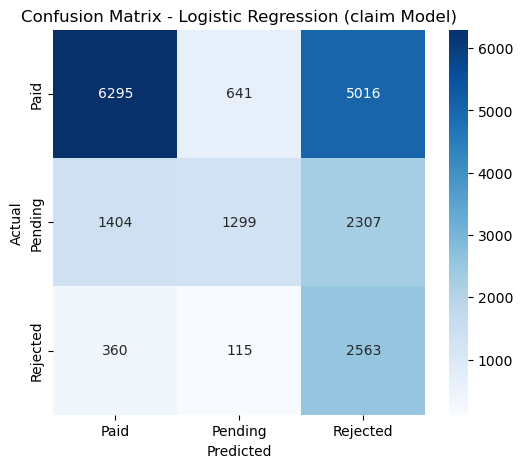

In [112]:
plt.figure(figsize=(6,5))

sns.heatmap(logistic_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (claim Model)")
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = logistic_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.352
              precision    recall  f1-score   support

           0       0.61      0.37      0.46      2988
           1       0.29      0.35      0.32      1253
           2       0.13      0.28      0.18       759

    accuracy                           0.35      5000
   macro avg       0.34      0.33      0.32      5000
weighted avg       0.45      0.35      0.38      5000



In [89]:
#confusion matrix
logistic_cm = confusion_matrix(y_test, y_pred)
print(logistic_cm)

[[1108  813 1067]
 [ 452  440  361]
 [ 268  279  212]]


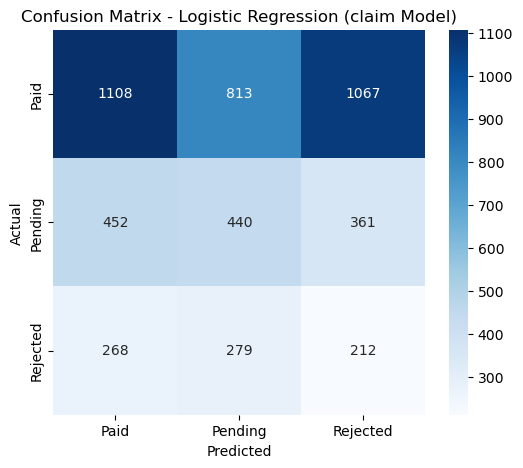

In [90]:
plt.figure(figsize=(6,5))

sns.heatmap(logistic_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (claim Model)")
plt.show()


In [66]:
randomforest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    bootstrap=False,
    n_jobs=-1
)


In [67]:
randomforest_model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,8
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [118]:
y_train_pred = randomforest_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))


Training Accuracy: 0.50785


In [105]:
y_train_pred = randomforest_model.predict(X_train)
print(classification_report(y_train, y_train_pred))


              precision    recall  f1-score   support

           0       0.78      0.53      0.63     11952
           1       0.63      0.26      0.37      5010
           2       0.26      0.84      0.40      3038

    accuracy                           0.51     20000
   macro avg       0.56      0.54      0.46     20000
weighted avg       0.66      0.51      0.53     20000



In [107]:
#confusion matrix
randomforest_cm_train = confusion_matrix(y_train, y_train_pred)
print(randomforest_cm_train)

[[6295  641 5016]
 [1404 1299 2307]
 [ 360  115 2563]]


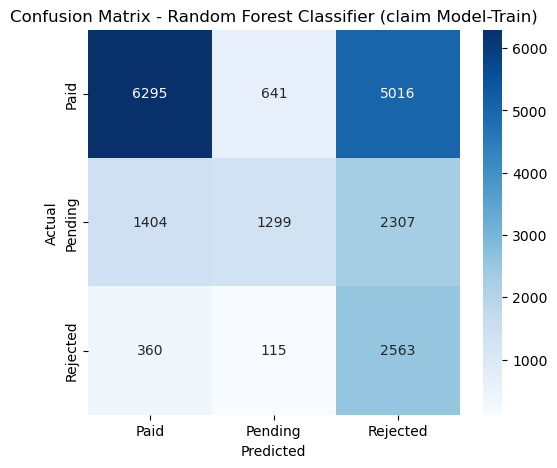

In [109]:
plt.figure(figsize=(6,5))

sns.heatmap(randomforest_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classifier (claim Model-Train)")
plt.show()

In [69]:
y_pred_rf = randomforest_model.predict(X_test)

print("RF Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


RF Test Accuracy: 0.4612
              precision    recall  f1-score   support

           0       0.75      0.50      0.60      2988
           1       0.47      0.19      0.27      1253
           2       0.23      0.74      0.35       759

    accuracy                           0.46      5000
   macro avg       0.48      0.48      0.41      5000
weighted avg       0.60      0.46      0.48      5000



In [93]:
#confusion matrix
randomforest_cm = confusion_matrix(y_test, y_pred_rf)
print(randomforest_cm)

[[1508  188 1292]
 [ 381  236  636]
 [ 119   78  562]]


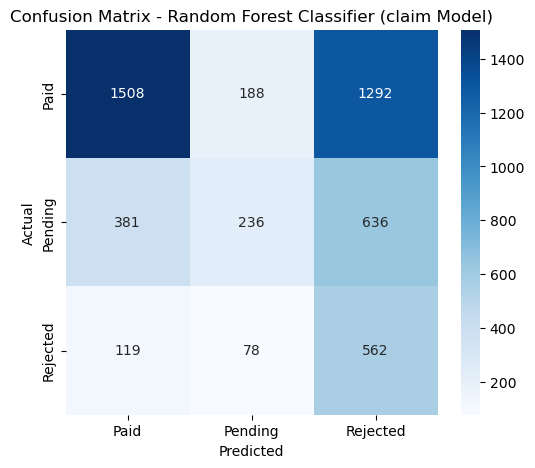

In [95]:
plt.figure(figsize=(6,5))

sns.heatmap(randomforest_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classifier (claim Model)")
plt.show()

In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.5577867023650156), np.int64(1): np.float64(1.3306719893546242), np.int64(2): np.float64(2.194426157559798)}


In [41]:
sample_weights = np.array([class_weight_dict[y] for y in y_train])


In [150]:
gb_model=HistGradientBoostingClassifier(
  learning_rate = 0.01,
  max_iter = 400,
  max_depth = 5,
  l2_regularization = 0.8,


)

In [151]:
gb_model.fit(X_train, y_train, sample_weight=sample_weights)


,loss,'log_loss'
,learning_rate,0.01
,max_iter,400
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,20
,l2_regularization,0.8
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [152]:

y_train_pred = gb_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Training Accuracy: 0.54425
              precision    recall  f1-score   support

           0       0.76      0.60      0.67     11952
           1       0.49      0.33      0.40      5010
           2       0.28      0.67      0.40      3038

    accuracy                           0.54     20000
   macro avg       0.51      0.53      0.49     20000
weighted avg       0.62      0.54      0.56     20000



In [147]:
#confusion matrix
gb_cm_train = confusion_matrix(y_train, y_train_pred)
print(gb_cm_train)

[[7047 1481 3424]
 [1554 1660 1796]
 [ 671  330 2037]]


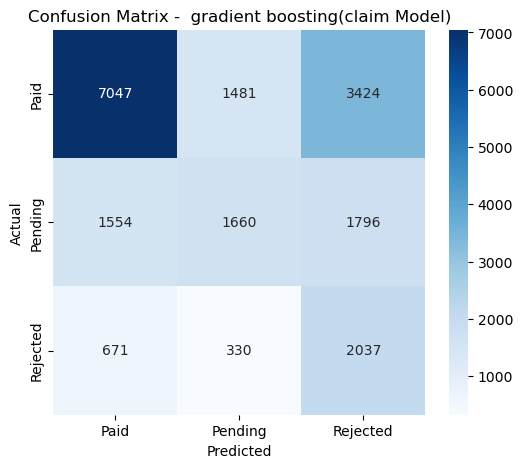

In [148]:
plt.figure(figsize=(6,5))

sns.heatmap(gb_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  gradient boosting(claim Model)")
plt.show()

In [149]:
y_pred_gb = gb_model.predict(X_test)

print("GB Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

GB Test Accuracy: 0.507
              precision    recall  f1-score   support

           0       0.74      0.57      0.65      2988
           1       0.41      0.30      0.35      1253
           2       0.26      0.60      0.36       759

    accuracy                           0.51      5000
   macro avg       0.47      0.49      0.45      5000
weighted avg       0.58      0.51      0.53      5000



In [97]:
#confusion matrix
gb_cm = confusion_matrix(y_test, y_pred_gb)
print(gb_cm)

[[1839  384  765]
 [ 454  363  436]
 [ 191  127  441]]


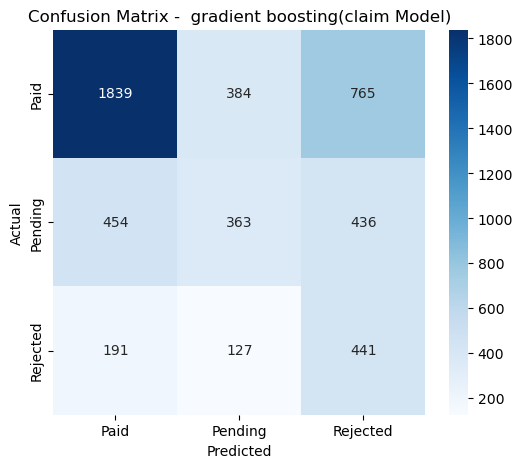

In [99]:
plt.figure(figsize=(6,5))

sns.heatmap(gb_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  gradient boosting(claim Model)")
plt.show()

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(0.5577867023650156), np.int64(1): np.float64(1.3306719893546242), np.int64(2): np.float64(2.194426157559798)}


In [47]:
sample_weights = np.array([class_weight_dict[y] for y in y_train])


In [81]:
from xgboost import XGBClassifier
xgb_model= XGBClassifier(
n_estimators = 250,
learning_rate = 0.01,
max_depth = 2,
subsample = 0.8,
colsample_bytree = 0.5,
reg_lambda = 1,
reg_alpha = 0,
objective = "multi:softprob",
num_class = 3,
eval_metric = "mlogloss")

In [82]:
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [115]:
y_train_pred = xgb_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Training Accuracy: 0.4675
              precision    recall  f1-score   support

           0       0.75      0.49      0.59     11952
           1       0.44      0.25      0.32      5010
           2       0.24      0.74      0.36      3038

    accuracy                           0.47     20000
   macro avg       0.48      0.49      0.42     20000
weighted avg       0.60      0.47      0.49     20000



In [121]:
#confusion matrix
xgb_cm_train = confusion_matrix(y_train, y_train_pred)
print(xgb_cm_train)

[[4228 3400 4324]
 [1884 1819 1307]
 [1078 1060  900]]


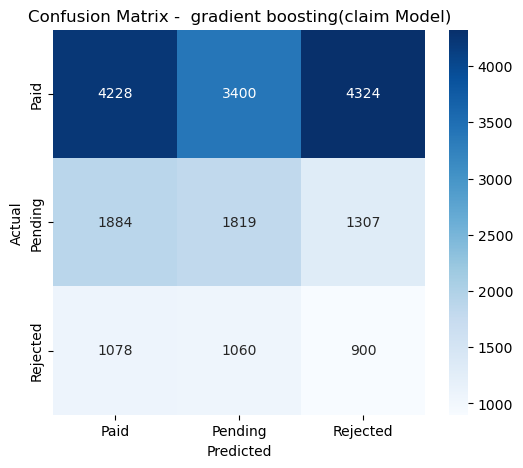

In [122]:
plt.figure(figsize=(6,5))

sns.heatmap(xgb_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  gradient boosting(claim Model)")
plt.show()

In [84]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGB Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB Test Accuracy: 0.4578
              precision    recall  f1-score   support

           0       0.75      0.49      0.59      2988
           1       0.40      0.23      0.29      1253
           2       0.23      0.71      0.35       759

    accuracy                           0.46      5000
   macro avg       0.46      0.48      0.41      5000
weighted avg       0.58      0.46      0.48      5000



In [100]:
#confusion matrix
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
print(xgb_cm)

[[1461  332 1195]
 [ 361  286  606]
 [ 125   92  542]]


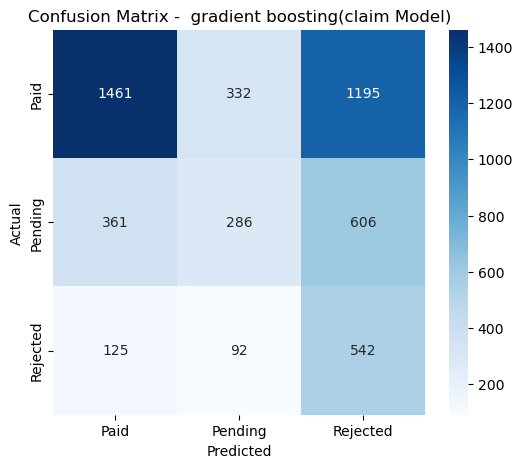

In [101]:
plt.figure(figsize=(6,5))

sns.heatmap(xgb_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_claim.classes_,
            yticklabels=le_claim.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  gradient boosting(claim Model)")
plt.show()

In [156]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = randomforest_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Show top 10
print(feature_importance_df.head(9))


                       feature  importance
0                billed_amount    0.350945
2                 payment_days    0.317804
1                bill_per_hour    0.131304
4         length_of_stay_hours    0.044001
6  avg_length_of_stay_patients    0.033728
7      days_since_registration    0.030029
8                          age    0.028853
5              visit_frequency    0.016160
3      provider_rejection_rate    0.006755


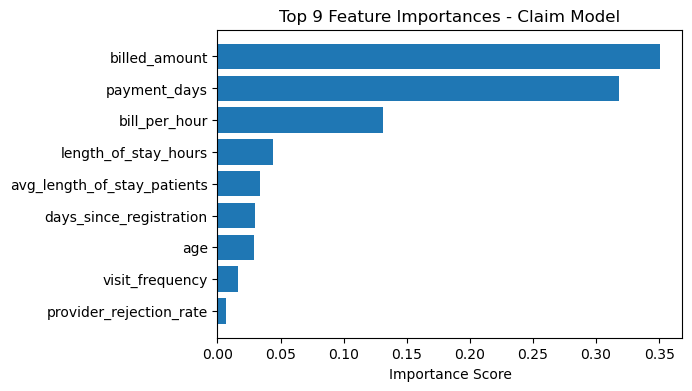

In [157]:
plt.figure(figsize=(6,4))

plt.barh(
    feature_importance_df.head(9)["feature"],
    feature_importance_df.head(9)["importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 9 Feature Importances - Claim Model")
plt.xlabel("Importance Score")
plt.show()


In [158]:
test_original = df.loc[X_test.index].copy()
test_original["actual"] = y_test
test_original["predicted"] = y_pred_rf

In [163]:
from sklearn.metrics import recall_score

for g in test_original["gender"].unique():
    subset = test_original[test_original["gender"] == g]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    # If Rejected = 2
    recall_rejected = recall_all[2]

    print(f"Gender: {g}, Rejected Recall: {recall_rejected:.2f}")

Gender: F, Rejected Recall: 0.74
Gender: M, Rejected Recall: 0.74


In [170]:
for g in test_original["gender"].unique():
    subset = test_original[test_original["gender"] == g]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    recall_rejected = recall_all[2]

    print(f"Gender: {g}, Rejected Recall: {recall_rejected:.2f}")

Gender: F, Rejected Recall: 0.74
Gender: M, Rejected Recall: 0.74


In [171]:
for c in test_original["city"].unique():
    subset = test_original[test_original["city"] == c]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    recall_rejected = recall_all[2]

    print(f"City: {c}, Rejected Recall: {recall_rejected:.2f}")

City: Chennai, Rejected Recall: 0.74
City: Mumbai, Rejected Recall: 0.75
City: Bangalore, Rejected Recall: 0.71
City: Pune, Rejected Recall: 0.68
City: Hyderabad, Rejected Recall: 0.80
City: Delhi, Rejected Recall: 0.78


In [172]:
for i in test_original["insurance_provider"].unique():
    subset = test_original[test_original["insurance_provider"] == i]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    recall_rejected = recall_all[2]

    print(f"Insurance: {i}, Rejected Recall: {recall_rejected:.2f}")

Insurance: HealthPlus, Rejected Recall: 0.72
Insurance: SecureLife, Rejected Recall: 0.68
Insurance: CareOne, Rejected Recall: 0.80
Insurance: MediCareX, Rejected Recall: 0.76


In [173]:
import joblib


In [174]:
joblib.dump(gb_model,"models/claim_model.pkl")

['models/claim_model.pkl']

In [175]:
joblib.dump(le_claim,"models/claim_label_encoder.pkl")

['models/claim_label_encoder.pkl']

In [176]:
joblib.dump(scaler,"models/claim_scaler.pkl")

['models/claim_scaler.pkl']

In [177]:
joblib.dump(X_train.columns.tolist(), "models/claim_final_columns.pkl")

['models/claim_final_columns.pkl']

In [179]:
loaded_model = joblib.load("models/claim_model.pkl")
loaded_scaler = joblib.load("models/claim_scaler.pkl")
print(loaded_model)
print(loaded_scaler)


HistGradientBoostingClassifier(l2_regularization=0.8, learning_rate=0.01,
                               max_depth=5, max_iter=400)
StandardScaler()


In [180]:
import json

In [181]:
claim_schema={
    "model_name": "Claim Outcome Classification",
    "target"    : "claim_status",
    "numerical_features": claim_num_cols,
    "categorical_features": claim_cat_cols
    }

In [182]:
with open("schema/claim_feature_schema.json", "w") as f:
    json.dump(claim_schema, f, indent=4)